In [1]:
import pandas as pd
dataset=pd.read_csv(r"C:\Users\Wow\Downloads\US_Top_50_Universities_2026.csv")

In [2]:
dataset.head()

,University_Name,National_Rank,Founded_Year,Institution_Type,State,Research_Impact_Score,Intl_Student_Ratio,Employment_Rate
0,Massachusetts Institute of Technology (MIT),1,1861,Private,MA,100.0,91.6,96.2
1,Columbia University,2,1754,Private,NY,95.9,83.7,92.1
2,Princeton University,3,1746,Private,NJ,99.0,70.0,94.5
3,Stanford University,4,1891,Private,CA,99.5,73.5,97.8
4,"University of California, Berkeley",5,1868,Public,CA,98.9,70.6,91.4


In [4]:
dataset_encoded=pd.get_dummies(dataset,columns=["University_Name","Institution_Type","State"])

In [7]:
from sklearn.cluster import KMeans

In [12]:
import matplotlib.pyplot as plt

In [13]:
x=dataset_encoded[["National_Rank","Founded_Year","Research_Impact_Score","Intl_Student_Ratio","Employment_Rate"]]

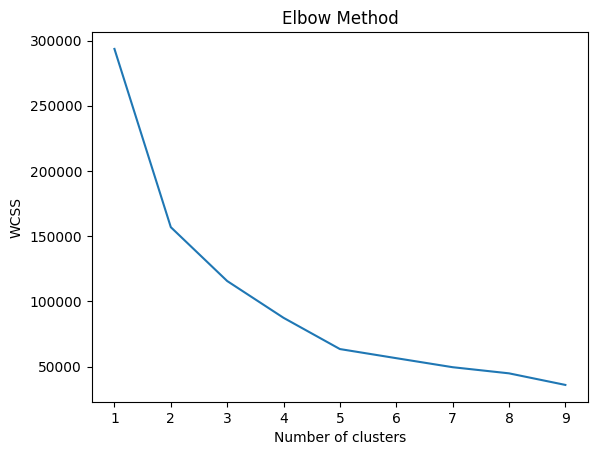

In [14]:
wcss = []

for i in range(1,10):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(x)
    wcss.append(kmeans.inertia_)

plt.plot(range(1,10), wcss)
plt.xlabel("Number of clusters")
plt.ylabel("WCSS")
plt.title("Elbow Method")
plt.show()

In [15]:
kmeans = KMeans(n_clusters=3, random_state=42)
dataset_encoded['Cluster'] = kmeans.fit_predict(x)

In [16]:
dataset_encoded['Cluster'].value_counts()

Cluster
1    24
0    20
2     6
Name: count, dtype: int64

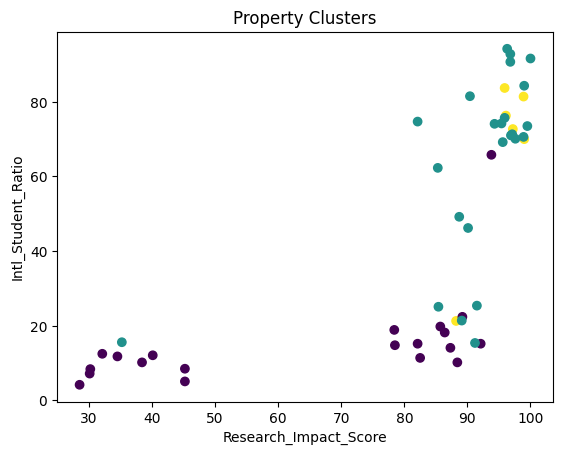

In [17]:
plt.scatter(dataset_encoded['Research_Impact_Score'], dataset_encoded['Intl_Student_Ratio'], 
            c=dataset_encoded['Cluster'])
plt.xlabel("Research_Impact_Score")
plt.ylabel("Intl_Student_Ratio")
plt.title("Property Clusters")
plt.show()